# Feature Engineering — YummyAnime Catalog

Input: `data/raw/anime_catalog.csv`  
Output: `data/processed/anime_features.csv`

### New features:
| # | Feature | Description |
|---|------|----------|
| 1 | `rating_tier` | Quality tier by rating (S/A/B/C/D) |
| 2 | `cross_platform_score` | Weighted average rating across all platforms |
| 3 | `popularity_score` | Normalized popularity (views × votes) |
| 4 | `engagement_rate` | Engagement: comments + reviews per 1000 views |
| 5 | `genre_count` | Number of genres |
| 6 | `is_multi_genre` | Flag: 3+ genres |
| 7 | `primary_genre` | Primary genre (first in list) |
| 8 | `genre_vector` | One-hot encoding of top-20 genres |
| 9 | `decade` | Release decade (80s / 90s / 2000s…) |
| 10 | `era` | Anime era (Classic / Modern / Contemporary) |
| 11 | `is_ongoing` | Ongoing flag |
| 12 | `is_movie` | Feature film flag |
| 13 | `type_simplified` | Simplified type (TV / Movie / OVA / Other) |
| 14 | `has_dubbing` | Has dubbing |
| 15 | `dubbing_count` | Number of dubbing studios |
| 16 | `studio_tier` | Studio tier (top / mid / indie / unknown) |
| 17 | `is_adaptation` | Adaptation flag (manga/light novel/game) |
| 18 | `hidden_gem` | High rating + few votes |
| 19 | `overrated_flag` | Many votes + below-average rating |
| 20 | `rating_consensus` | Rating consensus across all platforms (std) |
| 21 | `yummy_vs_mal_diff` | Difference between YummyAnime and MAL ratings |
| 22 | `community_activity` | Total community activity (comments + reviews + votes) |
| 23 | `slug` | Slug from URL (for joining with other tables) |

In [1]:
import pandas as pd
import numpy as np
import re
import os
from pathlib import Path


df = pd.read_csv('../../data/raw/anime_checkpoint_2300.csv')
print(f'Rows loaded: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Rows loaded: 2299
Columns: ['title_ru', 'alt_names', 'anime_id', 'status', 'type', 'year', 'age_rating', 'genres', 'source', 'studio', 'director', 'dubbing', 'site_rating', 'site_votes', 'site_views', 'shikimori_rating', 'shikimori_url', 'worldart_rating', 'worldart_url', 'kinopoisk_rating', 'kinopoisk_url', 'mal_rating', 'mal_url', 'comments_count', 'reviews_count', 'url']


,title_ru,alt_names,anime_id,status,type,year,age_rating,genres,source,studio,...,shikimori_url,worldart_rating,worldart_url,kinopoisk_rating,kinopoisk_url,mal_rating,mal_url,comments_count,reviews_count,url
0,Волшебница-медсестра Комуги-тян R,Nurse Witch Komugi R | Nurse Witch Komugi-chan...,10143,вышел,Сериал,Зима 2016,PG-13,Комедия | Пародия | Фэнтези,оригинальная идея,Tatsunoko Production,...,NaN,NaN,NaN,NaN,//kinopoisk.ru/film/973742,NaN,NaN,NaN,NaN,https://old.yummyani.me/catalog/item/volshebni...
1,Кровь-С,Blood-C | Кров-С | Кровь-C | ブラッドシー,7212,вышел,Сериал,Лето 2011,R-17+,Детектив | Ужасы | Фэнтези | Вампиры | Экшен |...,Оригинальная идея,Production I.G,...,NaN,NaN,NaN,6.0,//kinopoisk.ru/film/585299,NaN,NaN,NaN,NaN,https://old.yummyani.me/catalog/item/krov-s
2,"Пожалуйста, Айпри",+Himitsu no AiPri 3rd Season | Onegai AiPri | ...,26891,онгоинг,Сериал,Весна 2026,PG,Музыка,Игра,OLM | Dongwoo A&E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://old.yummyani.me/catalog/item/onegai-aipri


## Preparation: Cleaning Numeric Fields

In [2]:
def to_float(series):
    """Converts a column to float, stripping whitespace and replacing N/A → NaN."""
    return (
        series.astype(str)
              .str.replace(r'[^\d.,]', '', regex=True)
              .str.replace(',', '.')
              .replace('', np.nan)
              .pipe(pd.to_numeric, errors='coerce')
    )

def to_int(series):
    return to_float(series).astype('Int64')

# Numeric ratings
df['site_rating_num']      = to_float(df['site_rating'])
df['shikimori_rating_num'] = to_float(df['shikimori_rating'])
df['mal_rating_num']       = to_float(df['mal_rating'])
df['worldart_rating_num']  = to_float(df['worldart_rating'])
df['kinopoisk_rating_num'] = to_float(df['kinopoisk_rating'])

# Activity counters
df['site_votes_num']    = to_int(df['site_votes'])
df['site_views_num']    = to_int(df['site_views'])
df['comments_num']      = to_int(df['comments_count'])
df['reviews_num']       = to_int(df['reviews_count'])

# Year
df['year_num'] = to_int(df['year'])

print('Numeric fields ready.')
df[['site_rating_num','shikimori_rating_num','mal_rating_num','site_views_num']].describe()

Numeric fields ready.


C:\Users\Huawei\AppData\Local\Temp\ipykernel_8812\4191004323.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace('', np.nan)
C:\Users\Huawei\AppData\Local\Temp\ipykernel_8812\4191004323.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace('', np.nan)
C:\Users\Huawei\AppData\Local\Temp\ipykernel_8812\4191004323.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the 

,site_rating_num,shikimori_rating_num,mal_rating_num,site_views_num
count,2299.000000,0.0,0.0,2299.0
mean,6.454545,NaN,NaN,77222.949543
std,1.780962,NaN,NaN,357424.45481
min,0.000000,NaN,NaN,370.0
25%,5.840000,NaN,NaN,6509.0
50%,6.780000,NaN,NaN,16465.0
75%,7.555000,NaN,NaN,41665.0
max,9.460000,NaN,NaN,9361967.0


## Features 1–2: Rating Metrics

In [3]:
# ── Feature 1: rating_tier ─────────────────────────────────────────────
# Use the best available rating (MAL or Shikimori — most reliable)
best_rating = df['shikimori_rating_num'].fillna(df['mal_rating_num']).fillna(df['site_rating_num'])

def rating_tier(r):
    if pd.isna(r) or r == 0:  return 'Unrated'
    if r >= 8.5:               return 'S'
    if r >= 7.5:               return 'A'
    if r >= 6.5:               return 'B'
    if r >= 5.0:               return 'C'
    return 'D'

df['rating_tier'] = best_rating.apply(rating_tier)
print('rating_tier:', df['rating_tier'].value_counts().to_dict())

rating_tier: {'B': 718, 'C': 707, 'A': 527, 'D': 147, 'Unrated': 104, 'S': 96}


cross_platform_score — mean: 6.7


<Axes: >

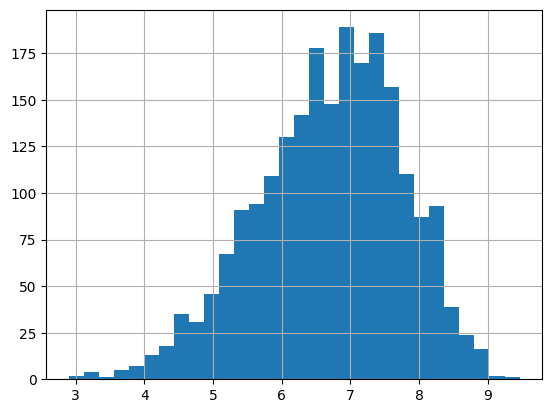

In [4]:
# ── Feature 2: cross_platform_score ────────────────────────────────────
# Normalize Shikimori/MAL (scale 1-10) and Kinopoisk (scale 1-10)
# Worldart — also 1-10. Site — 0-10.
# Weights: MAL=0.35, Shiki=0.30, Worldart=0.20, Site=0.10, Kino=0.05

weights = {
    'mal_rating_num':       0.35,
    'shikimori_rating_num': 0.30,
    'worldart_rating_num':  0.20,
    'site_rating_num':      0.10,
    'kinopoisk_rating_num': 0.05,
}

def weighted_cross_score(row):
    total_w, total_score = 0.0, 0.0
    for col, w in weights.items():
        val = row[col]
        if pd.notna(val) and val > 0:
            total_score += val * w
            total_w     += w
    return round(total_score / total_w, 2) if total_w > 0 else np.nan

df['cross_platform_score'] = df.apply(weighted_cross_score, axis=1)
print('cross_platform_score — mean:', df['cross_platform_score'].mean().round(2))
df['cross_platform_score'].hist(bins=30)

## Features 3–4: Popularity and Engagement

In [5]:
# ── Feature 3: popularity_score ─────────────────────────────────────────
# log1p(views) * log1p(votes) — remove outliers via logarithm

views = df['site_views_num'].fillna(0).clip(lower=0)
votes = df['site_votes_num'].fillna(0).clip(lower=0)

raw_pop = np.log1p(views) * np.log1p(votes)
# Normalize to 0–100
pop_max = raw_pop.max()
df['popularity_score'] = (raw_pop / pop_max * 100).round(2) if pop_max > 0 else 0.0

print('popularity_score top-5:')
print(df[['title_ru','popularity_score']].sort_values('popularity_score', ascending=False).head())

popularity_score top-5:
                                              title_ru  popularity_score
175   Поднятие уровня в одиночку 2: Восстаньте из тени             100.0
1088                                         Гачиакута             98.23
1329               Провожающая в последний путь Фрирен             96.32
729                             Хантер х Хантер (2011)             92.88
1318                              Монолог фармацевта 2             92.87


In [6]:
# ── Feature 4: engagement_rate ──────────────────────────────────────────
# (comments + reviews * 5) / views * 1000
# Reviews are multiplied by 5 — they are more valuable than comments

comments = df['comments_num'].fillna(0)
reviews  = df['reviews_num'].fillna(0)
views_safe = df['site_views_num'].fillna(0).replace(0, np.nan)

df['engagement_rate'] = ((comments + reviews * 5) / views_safe * 1000).round(3)
print('engagement_rate — median:', df['engagement_rate'].median().round(3))

engagement_rate — median: 0.0


## Features 5–8: Genre Features

In [7]:
# Parse genres column (stored as 'Action | Fantasy | Comedy')
def parse_genres(s):
    if pd.isna(s) or s in ('N/A', ''):
        return []
    return [g.strip() for g in re.split(r'[|,;]', str(s)) if g.strip()]

df['genres_list'] = df['genres'].apply(parse_genres)

# ── Feature 5: genre_count ──────────────────────────────────────────────
df['genre_count'] = df['genres_list'].apply(len)

# ── Feature 6: is_multi_genre ───────────────────────────────────────────
df['is_multi_genre'] = (df['genre_count'] >= 3).astype(int)

# ── Feature 7: primary_genre ────────────────────────────────────────────
df['primary_genre'] = df['genres_list'].apply(lambda g: g[0] if g else 'Unknown')

print('genre_count — distribution:')
print(df['genre_count'].value_counts().sort_index().head(10))
print('\nprimary_genre — top-10:')
print(df['primary_genre'].value_counts().head(10))

genre_count — distribution:
genre_count
0      9
1    128
2    246
3    407
4    488
5    397
6    272
7    167
8     91
9     48
Name: count, dtype: int64

primary_genre — top-10:
primary_genre
Сёнэн          494
Сэйнэн         312
Комедия        304
Драма          233
Приключения    203
Сёдзё           99
Фэнтези         96
Этти            84
Детектив        79
Меха            50
Name: count, dtype: int64


In [8]:
# ── Feature 8: genre_vector (one-hot top-20 genres) ─────────────────────
from collections import Counter

all_genres = [g for gl in df['genres_list'] for g in gl]
top_genres = [g for g, _ in Counter(all_genres).most_common(20)]

for genre in top_genres:
    col = 'genre_' + re.sub(r'[^\u0400-\u04ffa-z0-9]', '_', genre.lower())
    df[col] = df['genres_list'].apply(lambda gl: int(genre in gl))

genre_cols = [c for c in df.columns if c.startswith('genre_')]
print(f'Created {len(genre_cols)} one-hot genre columns:')
print(genre_cols)

Created 21 one-hot genre columns:
['genre_count', 'genre_комедия', 'genre_экшен', 'genre_фэнтези', 'genre_приключения', 'genre_драма', 'genre_фантастика', 'genre_сёнэн', 'genre_романтика', 'genre_школьная_жизнь', 'genre_сэйнэн', 'genre_сверхъестественное', 'genre_повседневность', 'genre_не_японское', 'genre_исторический', 'genre_меха', 'genre_детектив', 'genre_этти', 'genre_суперспособности', 'genre_боевые_искусства', 'genre_сёдзё']


## Features 9–10: Time-based Features

In [9]:
# ── Feature 9: decade ────────────────────────────────────────────────────
def to_decade(y):
    if pd.isna(y): return 'Unknown'
    y = int(y)
    return f"{(y // 10) * 10}s"

df['decade'] = df['year_num'].apply(to_decade)

# ── Feature 10: era ──────────────────────────────────────────────────────
def to_era(y):
    if pd.isna(y): return 'Unknown'
    y = int(y)
    if y < 1990:   return 'Classic'        # before 1990
    if y < 2000:   return 'Golden Age'     # 1990s
    if y < 2010:   return 'Modern'         # 2000s
    if y < 2020:   return 'Contemporary'   # 2010s
    return 'Recent'                         # 2020+

df['era'] = df['year_num'].apply(to_era)

print('decade:', df['decade'].value_counts().sort_index().to_dict())
print('era:',    df['era'].value_counts().to_dict())

decade: {'1910s': 1, '1920s': 1, '1930s': 1, '1940s': 2, '1950s': 4, '1960s': 6, '1970s': 25, '1980s': 110, '1990s': 205, '2000s': 381, '2010s': 757, '2020s': 752, 'Unknown': 54}
era: {'Contemporary': 757, 'Recent': 752, 'Modern': 381, 'Golden Age': 205, 'Classic': 150, 'Unknown': 54}


## Features 11–13: Anime Type

In [10]:
type_col = df['type'].fillna('').astype(str).str.lower()

# ── Feature 11: is_ongoing ───────────────────────────────────────────────
df['is_ongoing'] = df['status'].fillna('').str.lower().str.contains(
    r'онго|ongoing|выходит|выпускается', regex=True
).astype(int)

# ── Feature 12: is_movie ────────────────────────────────────────────────
df['is_movie'] = type_col.str.contains(
    r'фильм|movie|полнометр', regex=True
).astype(int)

# ── Feature 13: type_simplified ─────────────────────────────────────────
def simplify_type(t):
    t = str(t).lower()
    if re.search(r'фильм|movie|полнометр',      t): return 'Movie'
    if re.search(r'ova|ова|oav',                t): return 'OVA'
    if re.search(r'ona|она|web',                t): return 'ONA'
    if re.search(r'сериал|tv|тв|сезон',         t): return 'TV'
    if re.search(r'special|спец|sp',            t): return 'Special'
    return 'Other'

df['type_simplified'] = df['type'].apply(simplify_type)

print('type_simplified:', df['type_simplified'].value_counts().to_dict())
print('is_movie:',        df['is_movie'].sum())
print('is_ongoing:',      df['is_ongoing'].sum())

type_simplified: {'TV': 1030, 'ONA': 393, 'Movie': 355, 'OVA': 308, 'Other': 213}
is_movie: 355
is_ongoing: 40


## Features 14–16: Dubbing and Studio

In [11]:
# ── Feature 14: has_dubbing ──────────────────────────────────────────────
df['has_dubbing'] = df['dubbing'].apply(
    lambda x: 0 if (pd.isna(x) or str(x).strip() in ('', 'N/A')) else 1
)

# ── Feature 15: dubbing_count ────────────────────────────────────────────
df['dubbing_count'] = df['dubbing'].apply(
    lambda x: len([d for d in str(x).split('|') if d.strip() and d.strip() != 'N/A'])
    if pd.notna(x) else 0
)

# ── Feature 16: studio_tier ─────────────────────────────────────────────
# List of top studios (by global recognition)
TOP_STUDIOS = {
    'ufotable', 'mappa', 'wit studio', 'bones', 'kyoto animation',
    'madhouse', 'trigger', 'a-1 pictures', 'cloverworks', 'j.c.staff',
    'sunrise', 'toei animation', 'gainax', 'studio ghibli', 'p.a. works',
    'shaft', 'deen', 'brain\'s base', 'production i.g', 'white fox'
}
MID_STUDIOS = {
    'silver link', 'feel', 'feel.', 'kinema citrus', 'seven arcs',
    'doga kobo', 'bridge', 'satelight', 'pine jam', 'lay-duce',
    'studio bind', 'c2c', 'connect', 'liden films'
}

def studio_tier(studio_str):
    if pd.isna(studio_str) or str(studio_str).strip() in ('', 'N/A'):
        return 'Unknown'
    s = str(studio_str).lower()
    for top in TOP_STUDIOS:
        if top in s: return 'Top'
    for mid in MID_STUDIOS:
        if mid in s: return 'Mid'
    return 'Indie'

df['studio_tier'] = df['studio'].apply(studio_tier)

print('has_dubbing:',  df['has_dubbing'].value_counts().to_dict())
print('studio_tier:',  df['studio_tier'].value_counts().to_dict())

has_dubbing: {1: 1896, 0: 403}
studio_tier: {'Indie': 1330, 'Top': 736, 'Mid': 124, 'Unknown': 109}


## Features 17–22: Analytical Features

In [12]:
# ── Feature 17: is_adaptation ───────────────────────────────────────────
ADAPTATION_SOURCES = r'манга|ранобэ|роман|light novel|manga|novel|игра|game|visual novel|веб-манга'
df['is_adaptation'] = df['source'].fillna('').str.lower().str.contains(
    ADAPTATION_SOURCES, regex=True
).astype(int)

print('is_adaptation:', df['is_adaptation'].value_counts().to_dict())

is_adaptation: {1: 1291, 0: 1008}


In [13]:
# ── Feature 18: hidden_gem ───────────────────────────────────────────────
# High rating (≥ 7.5 by cross_platform) + few votes (bottom 30%)

votes_30pct = df['site_votes_num'].quantile(0.30)

df['hidden_gem'] = (
    (df['cross_platform_score'] >= 7.5) &
    (df['site_votes_num'] <= votes_30pct) &
    (df['site_votes_num'] > 0)
).astype(int)

print(f'hidden_gem: {df["hidden_gem"].sum()} anime')
print(df[df['hidden_gem']==1][['title_ru','cross_platform_score','site_votes_num']].head(10))

hidden_gem: 16 anime
                                           title_ru  cross_platform_score  \
193                  Югио! Тёмная сторона измерений                  7.60   
197                                     Король ночи                  7.67   
268                   Прекрасное путешествие Куроми                  7.62   
403                               Одержимый мужчина                  7.75   
751                 Формула жизни: Формула умиления                  8.00   
818   Галактический экспресс: Млечное метро — Фильм                  8.25   
820              Люпен III: Бессмертная родословная                  8.50   
993                Вольтрон: Легендарный защитник 2                  7.92   
1171                                   Время Йо-Кай                  8.86   
1665                  Народные сказки из будущего 2                  8.20   

      site_votes_num  
193               15  
197                9  
268               13  
403                4  
751             

In [14]:
# ── Feature 19: overrated_flag ───────────────────────────────────────────
# Many votes (top 30%) + cross_platform below average

votes_70pct = df['site_votes_num'].quantile(0.70)
mean_score  = df['cross_platform_score'].mean()

df['overrated_flag'] = (
    (df['site_votes_num'] >= votes_70pct) &
    (df['cross_platform_score'] < mean_score)
).astype(int)

print(f'overrated_flag: {df["overrated_flag"].sum()} anime')
print(df[df['overrated_flag']==1][['title_ru','cross_platform_score','site_votes_num']].head(10))

overrated_flag: 90 anime
                                              title_ru  cross_platform_score  \
1                                              Кровь-С                  6.59   
30                           Агент времени: Спецвыпуск                  6.61   
100                                    Судьба/Прототип                  6.33   
111                                Убийца Акамэ! Театр                  6.32   
113  Руководство гениального принца по вызволению с...                  6.20   
115     Почему-то в моём доме поселилась куноити-отаку                  5.72   
117                     Повелитель: Урок хороших манер                  6.33   
120         Ван-Пис: Цельсь! Пиратские короли бейсбола                  6.48   
162                                   Романс валькирий                  6.16   
204      Поднятие уровня в одиночку: Как стать сильнее                  6.52   

     site_votes_num  
1               328  
30              284  
100             259  
111   

In [15]:
# ── Feature 20: rating_consensus ─────────────────────────────────────────
# Standard deviation of ratings across all platforms:
# low std = platforms agree, high = platforms disagree

rating_cols = ['site_rating_num','shikimori_rating_num','mal_rating_num',
               'worldart_rating_num','kinopoisk_rating_num']

df['rating_consensus'] = df[rating_cols].apply(
    lambda row: round(row.dropna().std(), 3) if row.notna().sum() >= 2 else np.nan,
    axis=1
)

print('rating_consensus — median std:', df['rating_consensus'].median())
print('Most controversial (high std):')
print(df[['title_ru','rating_consensus']].dropna().sort_values('rating_consensus', ascending=False).head(5))

rating_consensus — median std: 0.438
Most controversial (high std):
                  title_ru  rating_consensus
2218  Стена великих воинов             3.514
918           Ванпанчмен 3             3.125
62      Облачный владыка 2             2.362
1654             Монсуно 2             2.256
1152               Стич! 3             1.980


In [16]:
# ── Feature 21: yummy_vs_mal_diff ────────────────────────────────────────
# Positive = YummyAnime rates higher than MAL (RU community favorite)
# Negative = MAL rates higher (global favorite)

df['yummy_vs_mal_diff'] = (df['site_rating_num'] - df['mal_rating_num']).round(2)

print('RU favorites (Yummy >> MAL):')
print(df[['title_ru','yummy_vs_mal_diff']].dropna()
        .sort_values('yummy_vs_mal_diff', ascending=False).head(5))

print('\nGlobal favorites (MAL >> Yummy):')
print(df[['title_ru','yummy_vs_mal_diff']].dropna()
        .sort_values('yummy_vs_mal_diff').head(5))

RU favorites (Yummy >> MAL):
Empty DataFrame
Columns: [title_ru, yummy_vs_mal_diff]
Index: []

Global favorites (MAL >> Yummy):
Empty DataFrame
Columns: [title_ru, yummy_vs_mal_diff]
Index: []


In [17]:
# ── Feature 22: community_activity ──────────────────────────────────────
# Total community activity: votes + comments + reviews*10

df['community_activity'] = (
    df['site_votes_num'].fillna(0) +
    df['comments_num'].fillna(0) +
    df['reviews_num'].fillna(0) * 10
).astype(int)

print('community_activity — top-10:')
print(df[['title_ru','community_activity']].sort_values('community_activity', ascending=False).head(10))

community_activity — top-10:
                                               title_ru  community_activity
175    Поднятие уровня в одиночку 2: Восстаньте из тени                9430
1329                Провожающая в последний путь Фрирен                8501
1893  Реинкарнация безработного: История о приключен...                7383
2092                                         Ванпанчмен                6916
1220                        Клинок, рассекающий демонов                6842
2258                                           Дандадан                6469
1041                                       Форма голоса                6099
45                             Паразит - Учение о жизни                5687
260                           Город, в котором меня нет                5684
1318                               Монолог фармацевта 2                5635


## Feature 23: Slug from URL

In [18]:
# ── Feature 23: slug ────────────────────────────────────────────────────
# Extract the last URL segment for easy joining with other tables

df['slug'] = df['url'].str.rstrip('/').str.split('/').str[-1]

print(df[['title_ru','slug']].head(5))

                                            title_ru  \
0                  Волшебница-медсестра Комуги-тян R   
1                                            Кровь-С   
2                                  Пожалуйста, Айпри   
3      Рейтинг короля: Сундук с сокровищами мужества   
4  Детектив Конан: Одиннадцатый нападающий — Филь...   

                                               slug  
0               volshebnica-medsestra-komugi-tyan-r  
1                                            krov-s  
2                                      onegai-aipri  
3  reyting-korolya-sunduk-s-sokrovischami-muzhestva  
4            detektiv-konan-16-odinnadcatyy-forvard  


## Summary

In [19]:
NEW_FEATURES = [
    'rating_tier', 'cross_platform_score', 'popularity_score', 'engagement_rate',
    'genre_count', 'is_multi_genre', 'primary_genre',
    'decade', 'era',
    'is_ongoing', 'is_movie', 'type_simplified',
    'has_dubbing', 'dubbing_count', 'studio_tier',
    'is_adaptation', 'hidden_gem', 'overrated_flag',
    'rating_consensus', 'yummy_vs_mal_diff', 'community_activity',
    'slug',
] + [c for c in df.columns if c.startswith('genre_')]

print(f'Total new features: {len(NEW_FEATURES)}')
df[NEW_FEATURES].describe(include='all').T[['count','unique','top','mean','std','min','max']]

Total new features: 43


,count,unique,top,mean,std,min,max
rating_tier,2299,6,B,NaN,NaN,NaN,NaN
cross_platform_score,2195.0,NaN,NaN,6.702597,1.059376,2.9,9.46
popularity_score,2299.0,<NA>,<NA>,29.264385,17.526312,0.0,100.0
engagement_rate,2299.0,<NA>,<NA>,0.0,0.0,0.0,0.0
genre_count,2299.0,NaN,NaN,4.469334,2.151222,0.0,16.0
is_multi_genre,2299.0,NaN,NaN,0.833406,0.372694,0.0,1.0
primary_genre,2299,38,Сёнэн,NaN,NaN,NaN,NaN
decade,2299,13,2010s,NaN,NaN,NaN,NaN
era,2299,6,Contemporary,NaN,NaN,NaN,NaN
is_ongoing,2299.0,NaN,NaN,0.017399,0.130781,0.0,1.0


In [20]:
# ── Save the final dataset ───────────────────────────────────────────────
# Keep all original columns + new features (excluding helper _num columns)

KEEP_ORIGINAL = [
    'anime_id','title_ru','alt_names','status','type','year','age_rating',
    'genres','source','studio','director','dubbing',
    'site_rating','site_votes','site_views',
    'shikimori_rating','shikimori_url',
    'worldart_rating','worldart_url',
    'kinopoisk_rating','kinopoisk_url',
    'mal_rating','mal_url',
    'comments_count','reviews_count','url'
]
# Filter to only existing columns
keep_orig = [c for c in KEEP_ORIGINAL if c in df.columns]

final_cols = keep_orig + [f for f in NEW_FEATURES if f not in keep_orig]
df_final   = df[final_cols].copy()

out_path = '../../data/processed/anime_features.csv'
df_final.to_csv(out_path, index=False, encoding='utf-8-sig')

print(f'Saved: {out_path}')
print(f'   Rows:    {len(df_final)}')
print(f'   Columns: {len(df_final.columns)}')
df_final.head(3)

Saved: ../../data/processed/anime_features.csv
   Rows:    2299
   Columns: 69


,anime_id,title_ru,alt_names,status,type,year,age_rating,genres,source,studio,...,genre_сверхъестественное,genre_повседневность,genre_не_японское,genre_исторический,genre_меха,genre_детектив,genre_этти,genre_суперспособности,genre_боевые_искусства,genre_сёдзё
0,10143,Волшебница-медсестра Комуги-тян R,Nurse Witch Komugi R | Nurse Witch Komugi-chan...,вышел,Сериал,Зима 2016,PG-13,Комедия | Пародия | Фэнтези,оригинальная идея,Tatsunoko Production,...,0,0,0,0,0,0,0,0,0,0
1,7212,Кровь-С,Blood-C | Кров-С | Кровь-C | ブラッドシー,вышел,Сериал,Лето 2011,R-17+,Детектив | Ужасы | Фэнтези | Вампиры | Экшен |...,Оригинальная идея,Production I.G,...,1,0,0,0,0,1,0,0,0,0
2,26891,"Пожалуйста, Айпри",+Himitsu no AiPri 3rd Season | Onegai AiPri | ...,онгоинг,Сериал,Весна 2026,PG,Музыка,Игра,OLM | Dongwoo A&E,...,0,0,0,0,0,0,0,0,0,0
